# Log-Space Neural Networks in Keras

This notebook presents a custom TensorFlow (TF)/Keras-compatible implementation of the dense/fully connected multilayer model where computations are performed in the **logarithmic domain** using LNS (Logarithmic Number System) arithmetic and the XLNS library.


- Comparisons with standard `Dense` layers from Keras

The aim is to explore the benefits of the possibility of training deep models in log-space while remaining compatible with TF/Keras.


In [ ]:
import tensorflow as tf
import numpy as np
import math
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
pip install xlns

In [ ]:
import xlns as xl

## Precision Settings
In this notebook, the TF backend is configured to operate using **float64** tensors, since xlns uses int64 encoding of scaled LNS representation of fp numbers, and it was observed that these numbers when converted to the default **float32** format would lose some precision crucial for determining their sign (using the last digit).

Furthermore, the notebook currently implements the fully-connected model eagerly and benchmarks it with eager keras dense models, however, some provisions have been made to support symbolic execution as well.

In [ ]:
tf.keras.backend.set_floatx('float64')


In [ ]:
tf.keras.config.floatx()

'float64'

In [ ]:
tf.config.run_functions_eagerly(True)

## Log-Space Arithmetic Functions

Although already defined in the xlns library, due to incompatibility with TF tensors, the notebook defines basic arithmetic operations that operate in the **logarithmic number system** that facilitate all forward and backward passes in the log-space neural network.

These include:
- Log-domain addition (`lns_add_int64`)
- Subtraction (`lns_sub_int64`)
- Multiplication (`lns_mul_int64`)
- Division (`lns_div_int64`)
- Matrix multiplication using LNS (`lns_matmul_int64`)


In [ ]:
def lns_to_float(x_data):
    """Converts tensors in LNS representation to float."""
    x = x_data // 2 #Getting the log magnitude
    s = x_data % 2 #the sign bit

    x_float = tf.pow(2.0, tf.cast(x, tf.float64) / (2**23))  #opposite shifting
    x_float = tf.where(tf.equal(s, 1), -x_float, x_float)

    return tf.cast(x_float,tf.float64)
def sbdb_ufunc_ideal2(x, sign_bit):
    """Helper function for obataining addition/subtraction correction term"""

    correction=tf.cast((((tf.math.log(tf.abs(1-2*tf.cast(sign_bit,tf.float64) +tf.pow(tf.cast(2.0,dtype=tf.float64),tf.cast((x/2**23),tf.float64))))/tf.math.log(tf.cast(2.0,tf.float64))))*2**23),tf.int64)*2 #+ tf.cast(sign_bit, tf.int64)#why adding sign_bit?? if sb==1 do substraction

    return correction

In [ ]:
@tf.custom_gradient
def lns_add_int64(x, y):
    """Addition of of 2 log-domain numbers using helper function sbdb_ufunc_ideal2"""




    y=tf.cast(y,tf.int64)
    x=tf.cast(x,tf.int64)

    max_part = tf.maximum(x, y)
    sign_bit_x=tf.bitwise.bitwise_and(x, 1)
    sign_bit_y=tf.bitwise.bitwise_and(y, 1)

    diff=(x // 2) - (y // 2)
    delta = -tf.abs(diff)
    sign_bit = tf.bitwise.bitwise_and(tf.bitwise.bitwise_xor(x, y), 1)




    correction = sbdb_ufunc_ideal2(delta, sign_bit)

    result= tf.cast(max_part + correction,tf.float64)
    result = tf.where(
    tf.logical_and(tf.equal(diff, 0), tf.equal(sign_bit, 1)),  # Condition for 0 handling
    tf.constant(-9223372036854775808, dtype=tf.float64),
    result
)


    def grad(dy,variables=None):
        """Gradients are returned with respect to each input"""


        return  dy,dy


    return result, grad

@tf.custom_gradient
def lns_sub_int64(x, y):
    """Subtracts two lns numbers"""
    x=tf.cast(x,tf.int64)
    y=tf.cast(y,tf.int64)
    result = lns_add_int64(x,y^1)  # Forward pass

    def grad(dy,variables=None):
        """Gradients are returned with respect to each input"""

        return dy, tf.cast(tf.cast(dy,tf.int64)^1,tf.float64)


    return result, grad



In [ ]:
def lns_mul_int64(x, y):
    """Returns multiplication result of two numbers in LNS representation by simply adding logs"""

    return x+y



def lns_div_int64(x, y):
    """Log domain division function; subtracts logs and handles corner cases with ufunc comparisons"""

    INT64_MIN = tf.constant(-9223372036854775808, dtype=tf.int64)  # Special zero representation in LNS
    INT64_MAX_positive = tf.constant(9223372036854775806, dtype=tf.int64) #will lead to float infinity
    INT64_MAX_negative = tf.constant(9223372036854775807, dtype=tf.int64)
    INT64_NAN = tf.constant(9223372036854775805, dtype=tf.int64)  # A placeholder for NaN

    x=tf.cast(x,tf.int64)
    y=tf.cast(y,tf.int64)
    is_nan = tf.logical_and(tf.equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    is_inf = tf.logical_and(tf.not_equal(x, INT64_MIN), tf.equal(y, INT64_MIN))


    normal_div = (x - y + (y & 1)) ^ (y & 1)
    inf_result = tf.where(x&1==1 , INT64_MAX_negative, INT64_MAX_positive)


    t_nd = tf.where(is_nan, INT64_NAN, #if else
            tf.where(is_inf, inf_result,
                     tf.where(tf.equal(x, INT64_MIN), INT64_MIN,
            normal_div)))  #otherwise


    return tf.cast(t_nd,tf.float64)

In [ ]:
#Vectorized Eager Matmul
@tf.custom_gradient
def lns_matmul_int64(A, B):
    """Optimized log-domain matmul using broadcasting."""
    if tf.rank(A) == 0 or tf.rank(B) == 0:
        result = A + B
    else:
        # Expand dimensions
        A_exp = tf.expand_dims(A, axis=2)  # (m, k, 1)
        B_exp = tf.expand_dims(B, axis=0)  # (1, k, n)

        products_log = A_exp + B_exp

        # Sum across the k dimension using lns_add_int64
        result = products_log[:, 0, :]
        for k in range(1, tf.shape(A)[1]):
            result = lns_add_int64(result, products_log[:, k, :])

    def grad(dy, variables=None):
        grad_a = lns_matmul_int64(dy, tf.transpose(B))
        grad_b = lns_matmul_int64(tf.transpose(A), dy)
        return grad_a, grad_b

    return result, grad


## Log-Space Model and Optimizer Definitions

Here, the main components of the log-space neural network are defined:

- `LogSpaceDense`: A fully connected layer where weights and activations are represented and computed in log-space.
- `log_mse_loss`: A log-domain version of the Mean Squared Error loss with custom gradients.
- `LogSpaceSGD`: A custom SGD optimizer adapted for log-space arithmetic.
- `log_relu`: Custom ReLU activation function for Log domain tensors

These components are built to integrate seamlessly with TF's model compilation and training using the Sequential API.

Furthermore, a 3 layer log-space fully connected model is defined and the task is to fit small regression functions such as `y = sin(x)` using normalized inputs. Training is performed entirely in the log-space domain, and results are later converted back to floating point for plotting. Validation is done separately visually


In [ ]:
@tf.custom_gradient
def log_relu(log_x):
  """Custom ReLU activation function for Log domain that uses last digit encoding (even/odd)"""

  log_x_r=tf.where(tf.cast(log_x,tf.int64)%2==1,tf.constant(xl.xlnsnp(np.array([0])).nd[0],dtype=tf.float64),log_x)
  def grad(dy,variables=None):

    dy=xl.xlnsnp(np.array(dy)).nd
    dy=tf.convert_to_tensor(dy,dtype=tf.float64)
    dy=tf.where(tf.cast(log_x,tf.int64)%2==1,tf.constant(xl.xlnsnp(np.array([0])).nd[0],dtype=tf.float64),dy)
    return dy
  return log_x_r, grad

In [ ]:

import tensorflow as tf
import numpy as np




class LogSpaceDense(tf.keras.layers.Layer):
    """
    Log-space Dense (fully connected) layer compatible with Keras,
    operating entirely in the log-domain using LNS representation.
    """

    def __init__(self, units,activation=None, **kwargs):
        """Initialization of layer parameters"""
        super(LogSpaceDense, self).__init__(**kwargs)
        self.units = units
        self.activation=activation

    def build(self, input_shape):
        """Creation of trainable log-domain weights and biases using custom LNS initializer."""
        input_dim = input_shape[-1]

        initial_w = tf.random.uniform(shape=(input_dim, self.units), minval=0.1, maxval=0.5, dtype=tf.float64)   #Proper ininitialization is essential
        initial_b = tf.random.uniform(shape=(self.units,), minval=0.001, maxval=0.01, dtype=tf.float64)


        self.log_w = self.add_weight(shape=(input_dim, self.units),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_w.numpy()).nd),
                                    trainable=True, dtype=tf.float64)
        self.log_b = self.add_weight(shape=(self.units,),
                                    initializer=tf.keras.initializers.Constant(xl.xlnsnp(initial_b.numpy()).nd),
                                    trainable=True, dtype=tf.float64)



    @tf.custom_gradient        #Decorator allows to define custom gradient for TF autograd
    def call(self, log_inputs):
        """Forward pass and custom gradient for log-space dense layer."""

        log_output = lns_add_int64(lns_matmul_int64(tf.cast(log_inputs,tf.float64), self.log_w), self.log_b)

        if self.activation:
            log_output = self.activation(log_output)   #ReLU will cause output to be 0 for w negative after large update;only bias will give output

        def grad(dy, variables=None):


            a=lns_matmul_int64(tf.transpose(log_inputs), dy)

            grad_log_w =a
            grad_log_b = dy[0]
            for i in range(1, tf.shape(dy)[0]):
                grad_log_b = lns_add_int64(grad_log_b, dy[i])

            grad_inputs = lns_matmul_int64(dy, tf.transpose(self.log_w)) #Transpose needed for backprop
            return grad_inputs, [grad_log_w, grad_log_b] #grad w for this layer, grad inputs for prev layer; tf goes full back, keeps storing all grad w,b then updates all layers w

        return tf.convert_to_tensor(log_output,dtype=tf.float64), grad
    def compute_output_shape(self, input_shape):
        """Define the output shape explicitly"""
        return (input_shape[0], self.units)


@tf.custom_gradient
def log_mse_loss(y_true_log, y_pred_log):
    """
    Custom Mean Squared Error loss function computed in the log-domain together with custom grad.
    """


    diff = lns_sub_int64(y_true_log, y_pred_log)
    diff_sq = lns_mul_int64(diff, diff)
    log_sum_se = diff_sq[0]
    for i in range(1, tf.shape(diff_sq)[0]):
        log_sum_se = lns_add_int64(log_sum_se, diff_sq[i])
    log_n=xl.xlnsnp(np.array([np.array(tf.size(y_true_log))])).nd[0]
    log_mse = log_sum_se - log_n

    def grad(dlog_mse,variables=None):

        dy = lns_mul_int64(tf.constant((2**24), dtype=tf.float64),  # ln(2) base 2 is just scaled 1
                           lns_sub_int64(y_pred_log, y_true_log))  -log_n


        dy=tf.where(tf.math.is_inf(lns_to_float(dy)), tf.constant(xl.xlnsnp(np.array([0])).nd[0], dtype=tf.float64), dy)



        dy_true = lns_mul_int64(0, lns_sub_int64(y_true_log, y_pred_log))

        return dy_true, dy

    return log_mse, grad




class LogSpaceSGD(tf.keras.optimizers.Optimizer):
    """Custom optimizer for log-space training.
  """
    def __init__(self, learning_rate=1, name="LogSpaceSGD", **kwargs):

        super().__init__(learning_rate, **kwargs)
        #self.learning_rate = tf.constant((np.log2(learning_rate) * (2**24)),dtype=tf.float64)
        self.learning_rate=xl.xlnsnp(np.array([learning_rate])).nd[0]
    def apply_gradients(self, grads_and_vars, name=None, experimental_aggregate_gradients=True):

        """Update rule for log-space weights."""

        for grad, var in grads_and_vars:

            if grad is not None:

                l=lns_mul_int64(self.learning_rate, grad)


                a=lns_sub_int64(var, l)

                a=tf.convert_to_tensor(xl.xlnsnp(np.array(lns_to_float(var)-lns_to_float(l))).nd,dtype=tf.float64)

                var.assign(a)

        return tf.no_op()

#Boston Housing
small 2-2 units model: LNS achieves 100 percent better performance than dense
medium sized 8-8 or 15-15 units model: LNS achieves around 10 percent better performance

x_train shape: (404, 13), y_train shape: (404,)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_6               │ (None, 2)              │            28 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_7               │ (None, 2)              │             6 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_8               │ (None, 1)              │             3 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (296.00 B)

 Trainable params: 37 (296.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 15s - 1s/step - loss: -4.6317e+07 - val_loss: -5.5875e+07
Epoch 2/100
13/13 - 13s - 1s/step - loss: -6.0778e+07 - val_loss: -6.1537e+07
Epoch 3/100
13/13 - 13s - 998ms/step - loss: -6.3926e+07 - val_loss: -6.2794e+07
Epoch 4/100
13/13 - 20s - 2s/step - loss: -6.5036e+07 - val_loss: -6.3436e+07
Epoch 5/100
13/13 - 21s - 2s/step - loss: -6.5590e+07 - val_loss: -6.3915e+07
Epoch 6/100
13/13 - 20s - 2s/step - loss: -6.5569e+07 - val_loss: -6.4315e+07
Epoch 7/100
13/13 - 20s - 2s/step - loss: -6.6418e+07 - val_loss: -6.4750e+07
Epoch 8/100
13/13 - 13s - 1s/step - loss: -6.6098e+07 - val_loss: -6.5141e+07
Epoch 9/100
13/13 - 20s - 2s/step - loss: -6.7639e+07 - val_loss: -6.5508e+07
Epoch 10/100
13/13 - 21s - 2s/step - loss: -6.6891e+07 - val_loss: -6.5857e+07
Epoch 11/100
13/13 - 13s - 995ms/step - loss: -6.7440e+07 - val_loss: -6.6177e+07
Epoch 12/100
13/13 - 20s - 2s/step - loss: -6.8120e+07 - val_loss: -6.6528e+07
Epoch 13/100
13/13 - 21s - 2s/step - loss: -6.8115e+07 - val_loss: 

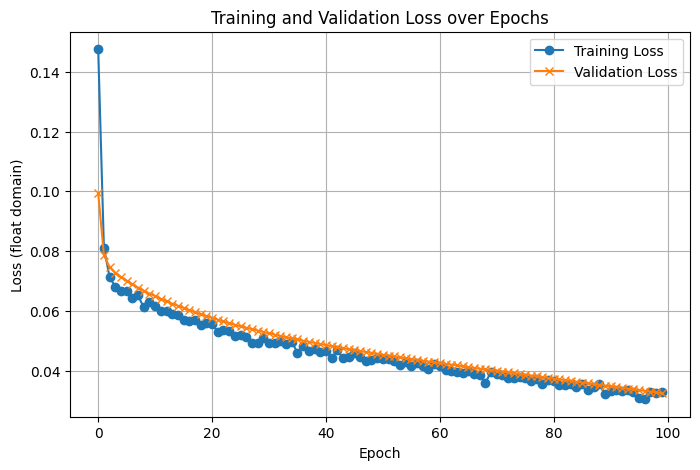

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

✅ Test MSE (original house price scale): 69.4032


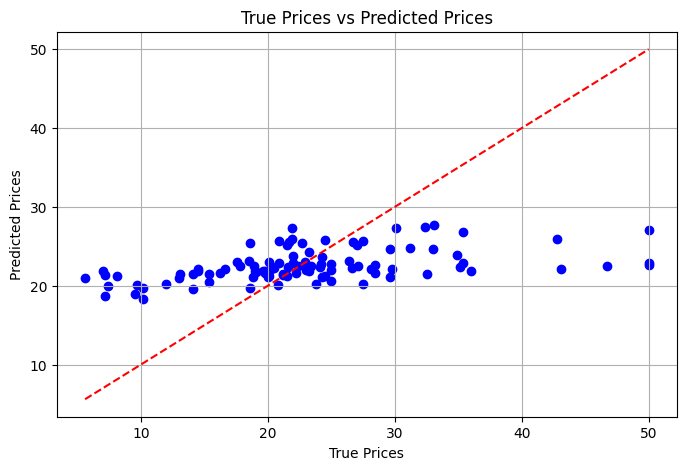

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from sklearn.metrics import mean_squared_error


(x_train_fp, y_train_fp), (x_test_fp, y_test_fp) = boston_housing.load_data()

print(f"x_train shape: {x_train_fp.shape}, y_train shape: {y_train_fp.shape}")


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scaled_data = (data - min_val) / (max_val - min_val + 1e-8)  # add small epsilon to avoid division by zero
    return scaled_data, min_val, max_val


x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min + 1e-8)


y_train_fp_normalized, y_min, y_max = min_max_scaling(y_train_fp)
y_test_fp_normalized = (y_test_fp - y_min) / (y_max - y_min + 1e-8)


x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd, dtype=tf.float64)

x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp_normalized).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(13,), dtype=tf.float64),  # 13 features
    LogSpaceDense(units=2, dtype=tf.float64, activation=log_relu),
    LogSpaceDense(units=2, dtype=tf.float64, activation=log_relu),
    LogSpaceDense(units=1, dtype=tf.float64, activation=None)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.01), loss=log_mse_loss)

model.summary()


history = model.fit(
    x_train_log,
    y_train_log,
    epochs=100,

    verbose=2,
    validation_data=(x_test_log, y_test_log)
)


loss_values = [lns_to_float(l) for l in history.history['loss']]
val_loss_values = [lns_to_float(l) for l in history.history['val_loss']]


plt.figure(figsize=(8,5))
plt.plot(loss_values, label='Training Loss', marker='o')
plt.plot(val_loss_values, label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (float domain)")
plt.legend()
plt.grid(True)
plt.show()

predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)


predictions_fp_rescaled = predictions_fp * (y_max - y_min) + y_min
y_true_fp_rescaled = (lns_to_float(y_test_log)) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(y_true_fp_rescaled), np.array(predictions_fp_rescaled))
print(f"\n Test MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 13s - 1s/step - loss: -8.3218e+07 - val_loss: -8.3153e+07
Epoch 2/100
13/13 - 12s - 947ms/step - loss: -8.5388e+07 - val_loss: -8.3363e+07
Epoch 3/100
13/13 - 13s - 998ms/step - loss: -8.3979e+07 - val_loss: -8.3549e+07
Epoch 4/100
13/13 - 21s - 2s/step - loss: -8.3951e+07 - val_loss: -8.3750e+07
Epoch 5/100
13/13 - 20s - 2s/step - loss: -8.4144e+07 - val_loss: -8.3948e+07
Epoch 6/100
13/13 - 13s - 984ms/step - loss: -8.4219e+07 - val_loss: -8.4141e+07
Epoch 7/100
13/13 - 13s - 1s/step - loss: -8.5827e+07 - val_loss: -8.4349e+07
Epoch 8/100
13/13 - 13s - 994ms/step - loss: -8.4289e+07 - val_loss: -8.4542e+07
Epoch 9/100
13/13 - 13s - 995ms/step - loss: -8.5269e+07 - val_loss: -8.4737e+07
Epoch 10/100
13/13 - 13s - 993ms/step - loss: -8.6406e+07 - val_loss: -8.4909e+07
Epoch 11/100
13/13 - 13s - 998ms/step - loss: -8.6014e+07 - val_loss: -8.5094e+07
Epoch 12/100
13/13 - 13s - 991ms/step - loss: -8.6400e+07 - val_loss: -8.5305e+07
Epoch 13/100
13/13 - 20s - 2s/step - loss: -8.522

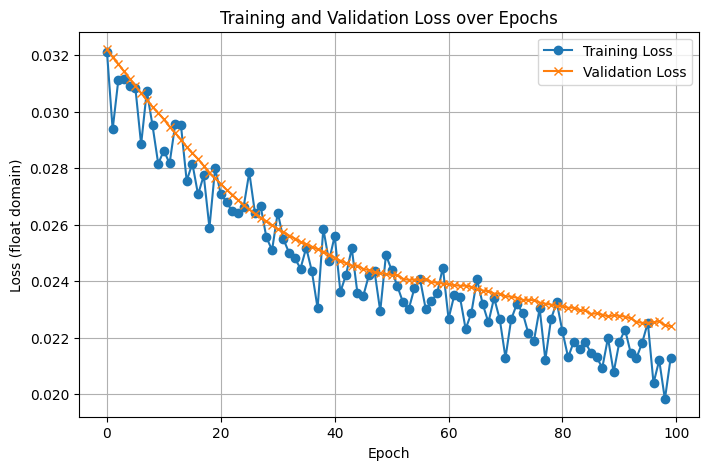

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

 Test MSE (original house price scale): 47.2285


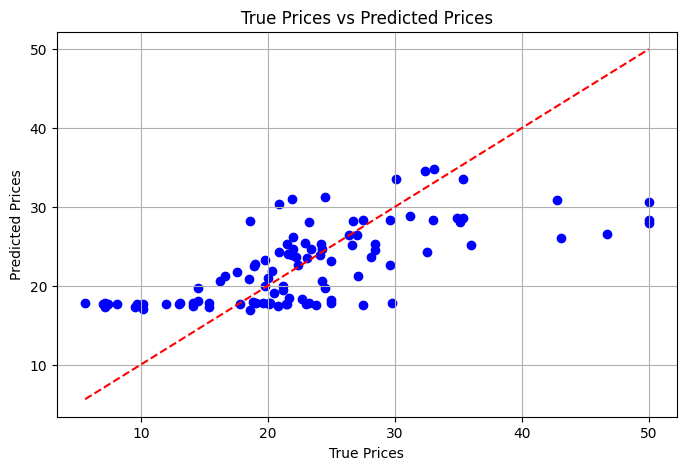

In [ ]:
#continuation of above
history = model.fit(
    x_train_log,
    y_train_log,
    epochs=100,

    verbose=2,
    validation_data=(x_test_log, y_test_log)
)


loss_values = [lns_to_float(l) for l in history.history['loss']]
val_loss_values = [lns_to_float(l) for l in history.history['val_loss']]


plt.figure(figsize=(8,5))
plt.plot(loss_values, label='Training Loss', marker='o')
plt.plot(val_loss_values, label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (float domain)")
plt.legend()
plt.grid(True)
plt.show()

predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)


predictions_fp_rescaled = predictions_fp * (y_max - y_min) + y_min
y_true_fp_rescaled = (lns_to_float(y_test_log)) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(y_true_fp_rescaled), np.array(predictions_fp_rescaled))
print(f"\n Test MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


In [ ]:
lns_to_float(-9.1939e+07)

<tf.Tensor: shape=(), dtype=float64, numpy=0.022405683752438874>

x_train shape: (404, 13), y_train shape: (404,)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 2)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 - 0s - 31ms/step - loss: 0.1635 - val_loss: 0.1403
Epoch 2/200
13/13 - 0s - 28ms/step - loss: 0.1131 - val_loss: 0.1014
Epoch 3/200
13/13 - 1s - 48ms/step - loss: 0.0836 - val_loss: 0.0780
Epoch 4/200
13/13 - 1s - 47ms/step - loss: 0.0663 - val_loss: 0.0639
Epoch 5/200
13/13 - 1s - 48ms/step - loss: 0.0560 - val_loss: 0.0552
Epoch 6/200
13/13 - 0s - 28ms/step - loss: 0.0499 - val_loss: 0.0502
Epoch 7/200
13/13 - 0s - 28ms/step - loss: 0.0465 - val_loss: 0.0472
Epoch 8/200
13/13 - 1s - 48ms/step - loss: 0.0444 - val_loss: 0.0452
Epoch 9/200
13/13 - 0s - 27ms/step - loss: 0.0431 - val_loss: 0.0439
Epoch 10/200
13/13 - 1s - 48ms/step - loss: 0.0423 - val_loss: 0.0431
Epoch 11/200
13/13 - 1s - 49ms/step - loss: 0.0419 - val_loss: 0.0426
Epoch 12/200
13/13 - 1s - 47ms/step - loss: 0.0416 - val_loss: 0.0423
Epoch 13/200
13/13 - 0s - 28ms/step - loss: 0.0414 - val_loss: 0.0421
Epoch 14/200
13/13 - 0s - 30ms/step - loss: 0.0412 - val_loss: 0.0419
Epoch 15/200
13/13 - 1s - 58m

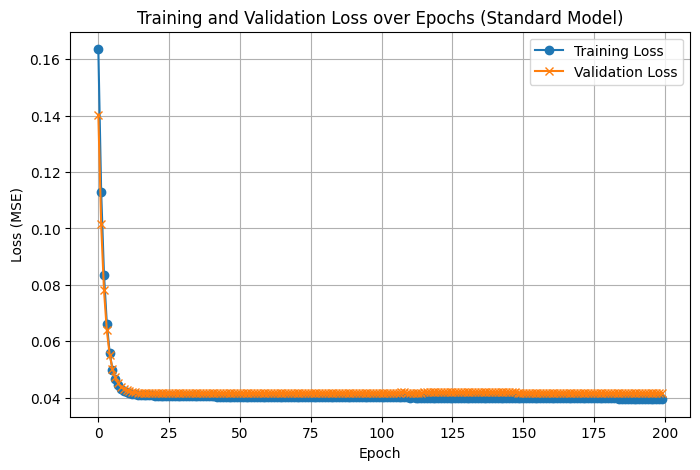

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Test MSE (original house price scale): 84.0531


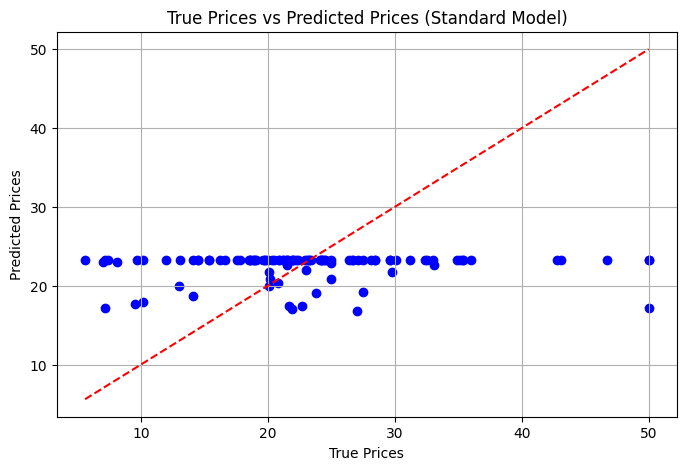

In [ ]:
#keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from sklearn.metrics import mean_squared_error


(x_train_fp, y_train_fp), (x_test_fp, y_test_fp) = boston_housing.load_data()

print(f"x_train shape: {x_train_fp.shape}, y_train shape: {y_train_fp.shape}")

def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scaled_data = (data - min_val) / (max_val - min_val + 1e-8)  # avoid division by zero
    return scaled_data, min_val, max_val


x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min + 1e-8)


y_train_fp_normalized, y_min, y_max = min_max_scaling(y_train_fp)
y_test_fp_normalized = (y_test_fp - y_min) / (y_max - y_min + 1e-8)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(13,), dtype=tf.float32),
    tf.keras.layers.Dense(units=2, activation='relu', dtype=tf.float32),
    tf.keras.layers.Dense(units=2, activation='relu', dtype=tf.float32),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float32)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()

history = model.fit(
    x_train_fp_normalized.astype(np.float32),
    y_train_fp_normalized.astype(np.float32),
    epochs=200,
    verbose=2,
    validation_data=(x_test_fp_normalized.astype(np.float32), y_test_fp_normalized.astype(np.float32))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp_normalized.astype(np.float32))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp_normalized * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


x_train shape: (404, 13), y_train shape: (404,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense (LogSpaceDense) │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_1               │ (None, 8)              │            72 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_2               │ (None, 1)              │             9 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (1.51 KB)

 Trainable params: 193 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 - 11s - 873ms/step - loss: -1.7611e+07 - val_loss: -6.3567e+07
Epoch 2/200
13/13 - 11s - 859ms/step - loss: -6.4900e+07 - val_loss: -6.4388e+07
Epoch 3/200
13/13 - 21s - 2s/step - loss: -6.6838e+07 - val_loss: -6.5200e+07
Epoch 4/200
13/13 - 12s - 930ms/step - loss: -6.7505e+07 - val_loss: -6.6158e+07
Epoch 5/200
13/13 - 33s - 3s/step - loss: -6.7311e+07 - val_loss: -6.6982e+07
Epoch 6/200
13/13 - 11s - 875ms/step - loss: -6.8474e+07 - val_loss: -6.7829e+07
Epoch 7/200
13/13 - 21s - 2s/step - loss: -6.9021e+07 - val_loss: -6.8582e+07
Epoch 8/200
13/13 - 12s - 894ms/step - loss: -7.0450e+07 - val_loss: -6.9324e+07
Epoch 9/200
13/13 - 22s - 2s/step - loss: -7.0646e+07 - val_loss: -6.9724e+07
Epoch 10/200
13/13 - 18s - 1s/step - loss: -7.0736e+07 - val_loss: -7.0206e+07
Epoch 11/200
13/13 - 10s - 797ms/step - loss: -7.1303e+07 - val_loss: -7.1390e+07
Epoch 12/200
13/13 - 21s - 2s/step - loss: -7.2165e+07 - val_loss: -7.2020e+07
Epoch 13/200
13/13 - 21s - 2s/step - loss: -7.2474e+07 

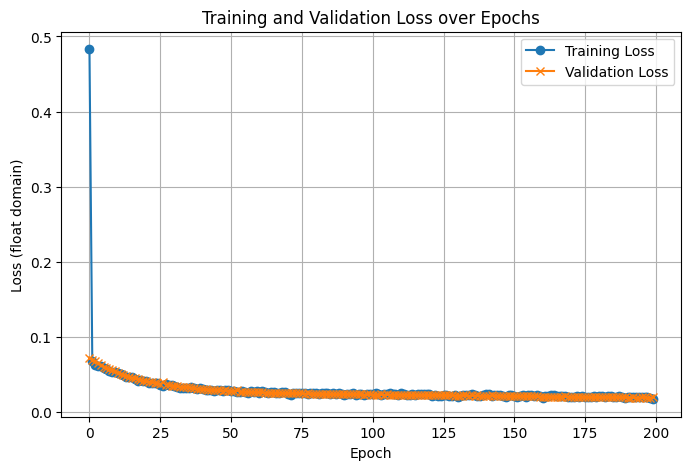

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

 Test MSE (original house price scale): 42.4231


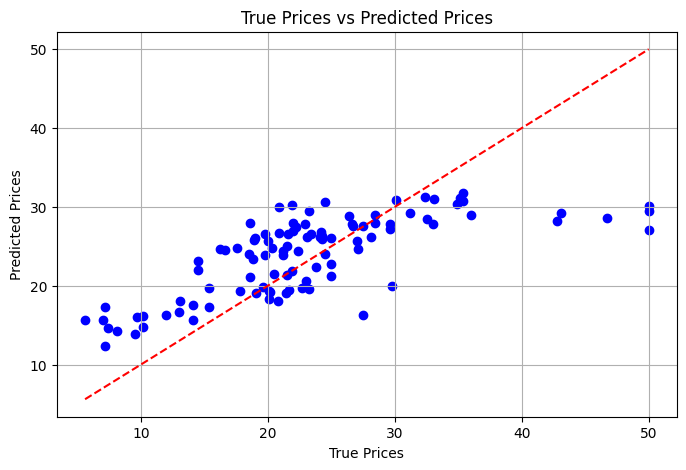

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from sklearn.metrics import mean_squared_error


(x_train_fp, y_train_fp), (x_test_fp, y_test_fp) = boston_housing.load_data()

print(f"x_train shape: {x_train_fp.shape}, y_train shape: {y_train_fp.shape}")


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scaled_data = (data - min_val) / (max_val - min_val + 1e-8)  # add small epsilon to avoid division by zero
    return scaled_data, min_val, max_val


x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min + 1e-8)


y_train_fp_normalized, y_min, y_max = min_max_scaling(y_train_fp)
y_test_fp_normalized = (y_test_fp - y_min) / (y_max - y_min + 1e-8)


x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp_normalized).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp_normalized).nd, dtype=tf.float64)

x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp_normalized).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp_normalized).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(13,), dtype=tf.float64),  # 13 features
    LogSpaceDense(units=8, dtype=tf.float64, activation=log_relu),
    LogSpaceDense(units=8, dtype=tf.float64, activation=log_relu),
    LogSpaceDense(units=1, dtype=tf.float64, activation=None)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.01), loss=log_mse_loss)

model.summary()


history = model.fit(
    x_train_log,
    y_train_log,
    epochs=200,

    verbose=2,
    validation_data=(x_test_log, y_test_log)
)


loss_values = [lns_to_float(l) for l in history.history['loss']]
val_loss_values = [lns_to_float(l) for l in history.history['val_loss']]


plt.figure(figsize=(8,5))
plt.plot(loss_values, label='Training Loss', marker='o')
plt.plot(val_loss_values, label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (float domain)")
plt.legend()
plt.grid(True)
plt.show()

predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)


predictions_fp_rescaled = predictions_fp * (y_max - y_min) + y_min
y_true_fp_rescaled = (lns_to_float(y_test_log)) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(y_true_fp_rescaled), np.array(predictions_fp_rescaled))
print(f"\n Test MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


In [ ]:
print(lns_to_float(-9.5610e+07))

tf.Tensor(0.01925263753436967, shape=(), dtype=float64)


x_train shape: (404, 13), y_train shape: (404,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 - 0s - 36ms/step - loss: 0.2628 - val_loss: 0.1863
Epoch 2/200
13/13 - 0s - 11ms/step - loss: 0.1521 - val_loss: 0.1322
Epoch 3/200
13/13 - 0s - 8ms/step - loss: 0.1192 - val_loss: 0.1092
Epoch 4/200
13/13 - 0s - 11ms/step - loss: 0.1022 - val_loss: 0.0959
Epoch 5/200
13/13 - 0s - 13ms/step - loss: 0.0908 - val_loss: 0.0869
Epoch 6/200
13/13 - 0s - 11ms/step - loss: 0.0829 - val_loss: 0.0803
Epoch 7/200
13/13 - 0s - 8ms/step - loss: 0.0769 - val_loss: 0.0752
Epoch 8/200
13/13 - 0s - 11ms/step - loss: 0.0721 - val_loss: 0.0711
Epoch 9/200
13/13 - 0s - 8ms/step - loss: 0.0680 - val_loss: 0.0675
Epoch 10/200
13/13 - 0s - 8ms/step - loss: 0.0644 - val_loss: 0.0645
Epoch 11/200
13/13 - 0s - 12ms/step - loss: 0.0614 - val_loss: 0.0619
Epoch 12/200
13/13 - 0s - 8ms/step - loss: 0.0588 - val_loss: 0.0595
Epoch 13/200
13/13 - 0s - 10ms/step - loss: 0.0565 - val_loss: 0.0573
Epoch 14/200
13/13 - 0s - 8ms/step - loss: 0.0543 - val_loss: 0.0553
Epoch 15/200
13/13 - 0s - 11ms/step

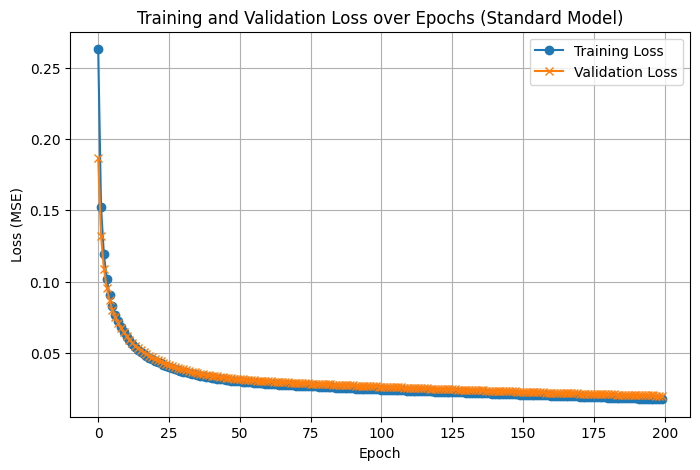

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Test MSE (original house price scale): 40.7071


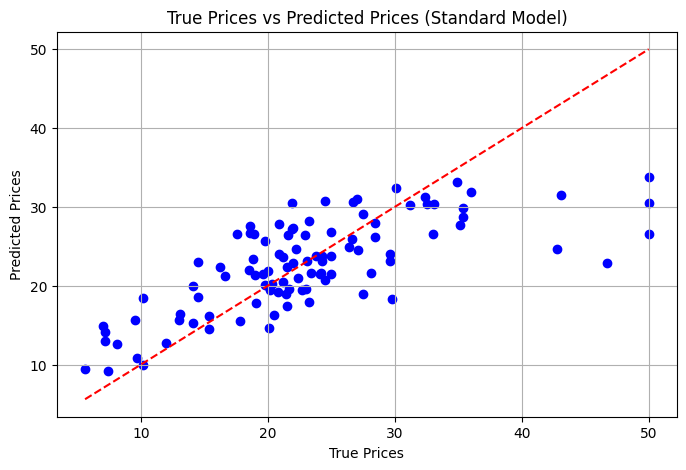

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import boston_housing
from sklearn.metrics import mean_squared_error


(x_train_fp, y_train_fp), (x_test_fp, y_test_fp) = boston_housing.load_data()

print(f"x_train shape: {x_train_fp.shape}, y_train shape: {y_train_fp.shape}")


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scaled_data = (data - min_val) / (max_val - min_val + 1e-8)  # avoid division by zero
    return scaled_data, min_val, max_val


x_train_fp_normalized, x_min, x_max = min_max_scaling(x_train_fp)
x_test_fp_normalized = (x_test_fp - x_min) / (x_max - x_min + 1e-8)


y_train_fp_normalized, y_min, y_max = min_max_scaling(y_train_fp)
y_test_fp_normalized = (y_test_fp - y_min) / (y_max - y_min + 1e-8)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(13,), dtype=tf.float32),
    tf.keras.layers.Dense(units=8, activation='relu', dtype=tf.float32),
    tf.keras.layers.Dense(units=8, activation='relu', dtype=tf.float32),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float32)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()


history = model.fit(
    x_train_fp_normalized.astype(np.float32),
    y_train_fp_normalized.astype(np.float32),
    epochs=200,
    verbose=2,
    validation_data=(x_test_fp_normalized.astype(np.float32), y_test_fp_normalized.astype(np.float32))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp_normalized.astype(np.float32))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp_normalized * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


#California Housing
5 unit lns 70 percent better than keras

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_36              │ (None, 5)              │            45 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_37              │ (None, 5)              │            30 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_38              │ (None, 1)              │             6 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (648.00 B)

 Trainable params: 81 (648.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 890ms/step - loss: -21953310.0000 - val_loss: -86820648.0000
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 882ms/step - loss: -85873224.0000 - val_loss: -91950336.0000
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 925ms/step - loss: -89526360.0000 - val_loss: -92355320.0000
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 874ms/step - loss: -88020760.0000 - val_loss: -92504504.0000
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 824ms/step - loss: -86147040.0000 - val_loss: -92519552.0000
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 850ms/step - loss: -84308776.0000 - val_loss: -92758040.0000
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 901ms/step - loss: -87918496.0000 - val_loss: -92825136.0000
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 839ms/step - loss: -87651576.0000 - val_loss: -92975656.0000
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 897ms/step - loss: -86000360.0000 - val_loss: -93221800.0000
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 875ms/step - loss: -88846944.0

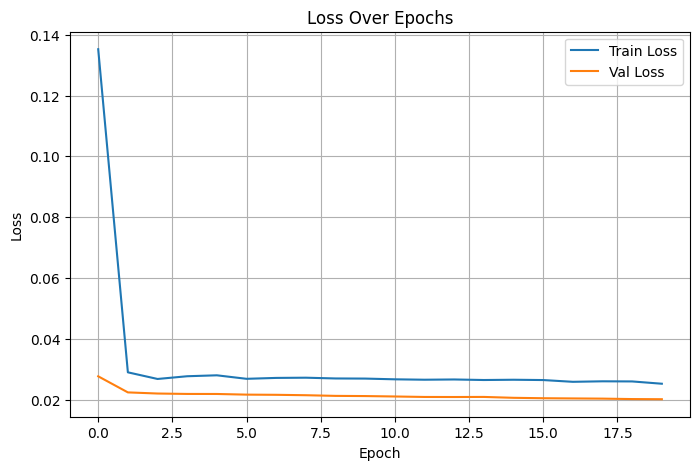

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error




data = fetch_california_housing()
x_fp, y_fp = data.data, data.target.reshape(-1, 1)


x_fp = x_fp[:1000]
y_fp = y_fp[:1000]


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)


x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp).nd, dtype=tf.float64)
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    LogSpaceDense(units=5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(units=5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.01), loss=log_mse_loss)
model.summary()


history = model.fit(
    x_train_log, y_train_log,
    epochs=20,
    validation_data=(x_test_log, y_test_log),
    verbose=1
)


predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)


predictions_rescaled = predictions_fp * (y_max - y_min) + y_min
true_rescaled = lns_to_float(y_test_log) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(true_rescaled), np.array(predictions_rescaled))
print(f"Test MSE: {mse:.4f}")

# Plot
loss_values = [lns_to_float(l) for l in history.history['loss']]
val_loss_values = [lns_to_float(l) for l in history.history['val_loss']]

plt.figure(figsize=(8, 5))
plt.plot(loss_values, label="Train Loss")
plt.plot(val_loss_values, label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lns_to_float(-94507032.0000)

<tf.Tensor: shape=(), dtype=float64, numpy=0.02015025531523019>

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (648.00 B)

 Trainable params: 81 (648.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.2418 - val_loss: 0.0491
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0557 - val_loss: 0.0429
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0566 - val_loss: 0.0423
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0514 - val_loss: 0.0407
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0473 - val_loss: 0.0385
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0456 - val_loss: 0.0377
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0411 - val_loss: 0.0375
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0473 - val_loss: 0.0372
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0463 - val_loss: 0.0369
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0446 - val_loss: 0.0367
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0429 - val_loss: 0.0365
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0476 - val_l

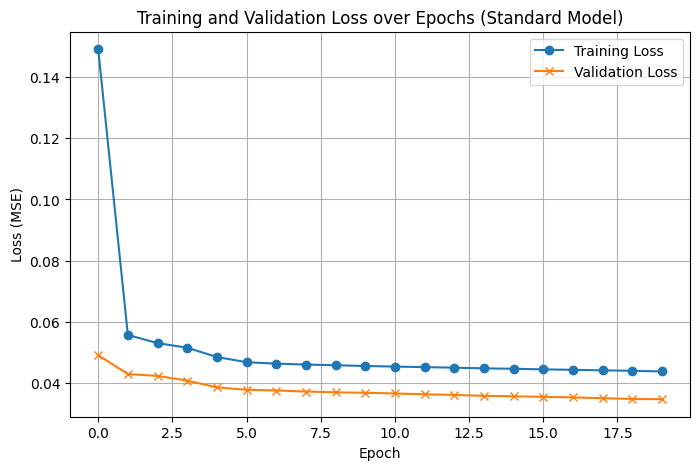

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Test MSE (original house price scale): 0.6707


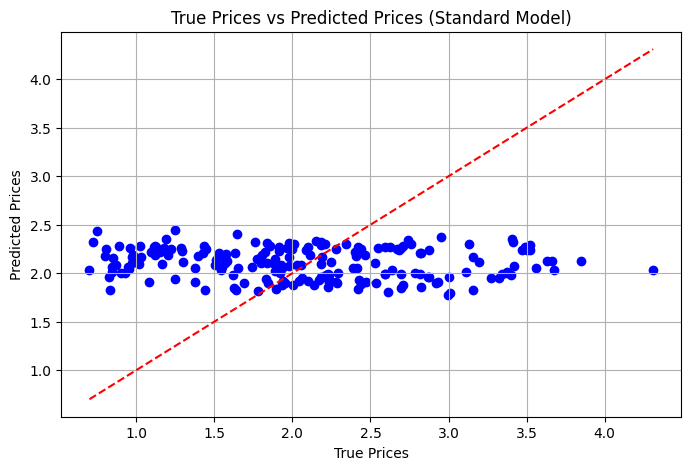

In [ ]:
#keras
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=20,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 15)             │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (3.05 KB)

 Trainable params: 391 (3.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0640 - val_loss: 0.0389
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - loss: 0.0345 - val_loss: 0.0295
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0276 - val_loss: 0.0256
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.0244 - val_loss: 0.0241
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0235 - val_loss: 0.0234
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0227 - val_loss: 0.0230
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0226 - val_loss: 0.0230
Epoch 8/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - loss: 0.0232 - val_loss: 0.0225
Epoch 9/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - loss: 0.0222 - val_loss: 0.0224
Epoch 10/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0220 - val_loss: 0.0223
Epoch 11/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.0223 - val_loss: 0.0221
Epoch 12/20
516/516 ━━━━━━━━━━

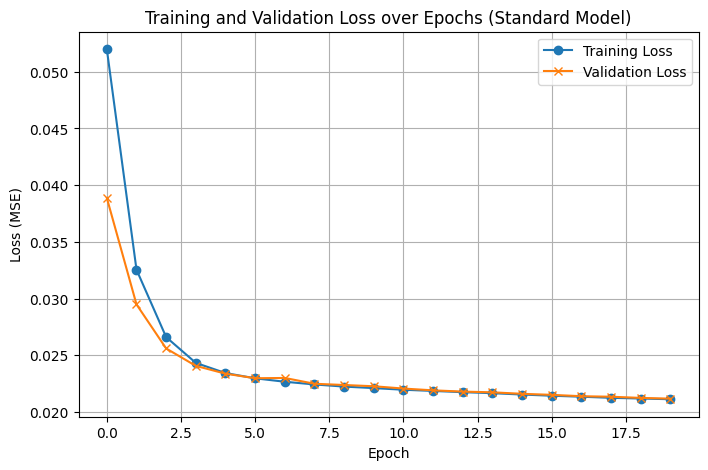

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Test MSE (original house price scale): 0.4983


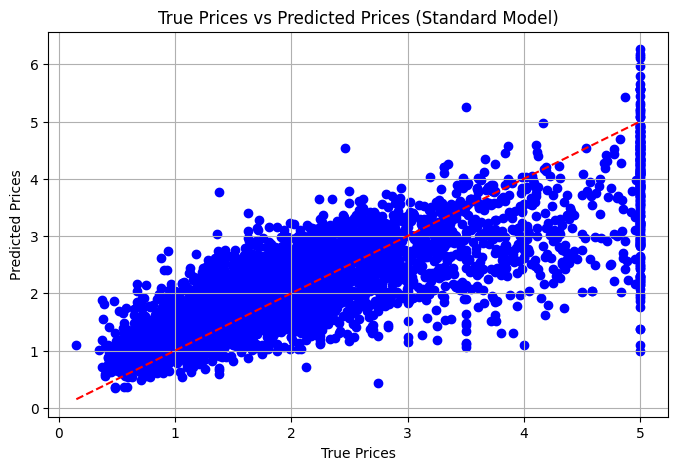

In [ ]:
#keras 15 units
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=20,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()

#DIABETES
15 unit model lns better than keras in 20 epochs also lns slightly better for over 50 epochs.
lns 22 percent better for 5 unit model

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_33              │ (None, 15)             │           165 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_34              │ (None, 15)             │           240 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_35              │ (None, 1)              │            16 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421 (3.29 KB)

 Trainable params: 421 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 42242288.0000 - val_loss: -63698224.0000
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - loss: -71145568.0000 - val_loss: -75751880.0000
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: -73532352.0000 - val_loss: -60375828.0000
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: -67181016.0000 - val_loss: -77944000.0000
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: -72755784.0000 - val_loss: -77255592.0000
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: -73184456.0000 - val_loss: -77427848.0000
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: -73214992.0000 - val_loss: -69803336.0000
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: -72493168.0000 - val_loss: -73753136.0000
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: -73471392.0000 - val_loss: -76736744.0000
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: -72704264.0000 - val_loss: -74991296.0000
Epoch 11/20

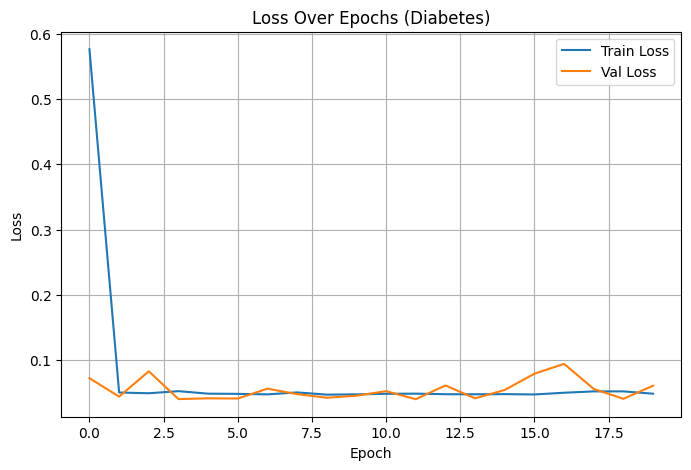

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = load_diabetes()
x_fp, y_fp = data.data, data.target.reshape(-1, 1)


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp).nd, dtype=tf.float64)
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    LogSpaceDense(15, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(15, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.001), loss=log_mse_loss)
model.summary()


history = model.fit(
    x_train_log, y_train_log,
    epochs=20,
    validation_data=(x_test_log, y_test_log),
    verbose=1
)


predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)

predictions_rescaled = predictions_fp * (y_max - y_min) + y_min
true_rescaled = lns_to_float(y_test_log) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(true_rescaled), np.array(predictions_rescaled))
print(f"Test MSE: {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([lns_to_float(l) for l in history.history['loss']], label="Train Loss")
plt.plot([lns_to_float(l) for l in history.history['val_loss']], label="Val Loss")
plt.title("Loss Over Epochs (Diabetes)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lns_to_float(-77696976.0000)

<tf.Tensor: shape=(), dtype=float64, numpy=0.040355226576974546>

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421 (3.29 KB)

 Trainable params: 421 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 0.1629 - val_loss: 0.1096
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.1328 - val_loss: 0.0997
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1327 - val_loss: 0.0916
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.1312 - val_loss: 0.0843
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.1111 - val_loss: 0.0787
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.1076 - val_loss: 0.0737
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0959 - val_loss: 0.0684
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0877 - val_loss: 0.0654
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0937 - val_loss: 0.0619
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0926 - val_loss: 0.0598
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0767 - val_loss: 0.0574
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0751 - val_

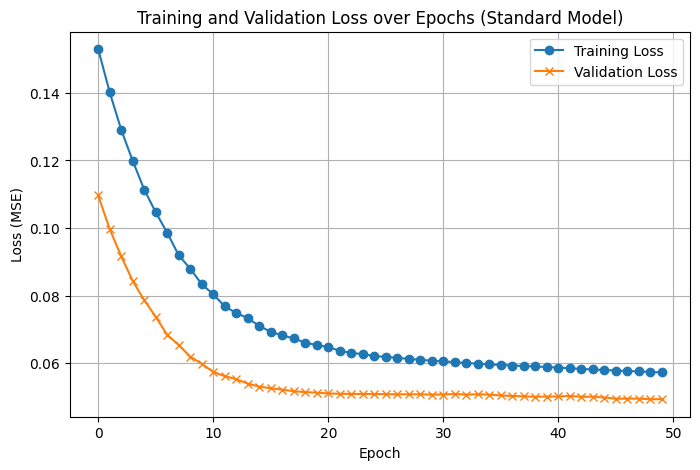

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Test MSE (original house price scale): 5085.8561


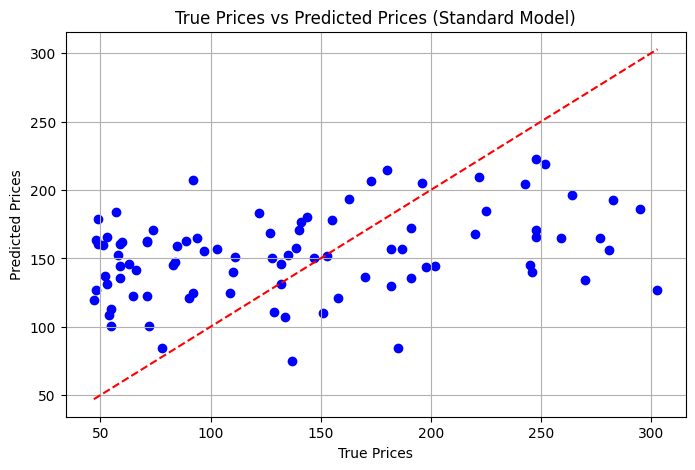

In [ ]:
#keras
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=50,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_21              │ (None, 5)              │            55 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_22              │ (None, 5)              │            30 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_23              │ (None, 1)              │             6 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (728.00 B)

 Trainable params: 91 (728.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 994ms/step - loss: 45632116.0000 - val_loss: 21447146.0000
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 865ms/step - loss: 16128870.0000 - val_loss: -1777524.5000
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 715ms/step - loss: -5896022.0000 - val_loss: -21237828.0000
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 778ms/step - loss: -24914870.0000 - val_loss: -37685420.0000
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 816ms/step - loss: -41325564.0000 - val_loss: -49744984.0000
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - loss: -61356704.0000 - val_loss: -64594396.0000
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 813ms/step - loss: -67671648.0000 - val_loss: -68827272.0000
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 808ms/step - loss: -69092152.0000 - val_loss: -70921056.0000
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 825ms/step - loss: -71116800.0000 - val_loss: -72159344.0000
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 727ms/step - loss: -72807552.0000 - val_loss: -72

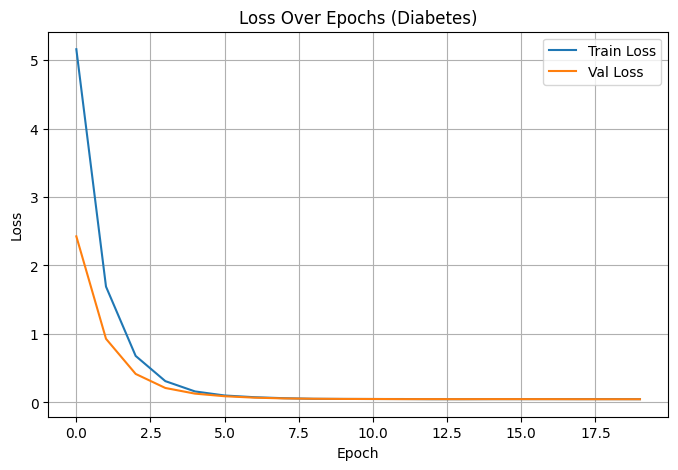

In [ ]:
#5unit
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = load_diabetes()
x_fp, y_fp = data.data, data.target.reshape(-1, 1)


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp).nd, dtype=tf.float64)
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    LogSpaceDense(5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.001), loss=log_mse_loss)
model.summary()


history = model.fit(
    x_train_log, y_train_log,
    epochs=20,
    validation_data=(x_test_log, y_test_log),
    verbose=1
)


predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)

predictions_rescaled = predictions_fp * (y_max - y_min) + y_min
true_rescaled = lns_to_float(y_test_log) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(true_rescaled), np.array(predictions_rescaled))
print(f"Test MSE: {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([lns_to_float(l) for l in history.history['loss']], label="Train Loss")
plt.plot([lns_to_float(l) for l in history.history['val_loss']], label="Val Loss")
plt.title("Loss Over Epochs (Diabetes)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lns_to_float(-74280952.0000)

<tf.Tensor: shape=(), dtype=float64, numpy=0.046472151308269156>

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (728.00 B)

 Trainable params: 91 (728.00 B)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.2307 - val_loss: 0.1700
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.2115 - val_loss: 0.1571
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - loss: 0.1853 - val_loss: 0.1455
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.1694 - val_loss: 0.1352
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - loss: 0.1656 - val_loss: 0.1245
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - loss: 0.1476 - val_loss: 0.1153
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.1242 - val_loss: 0.1081
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.1238 - val_loss: 0.1019
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1243 - val_loss: 0.0962
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.1087 - val_loss: 0.0913
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.1131 - val_loss: 0.0868
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss:

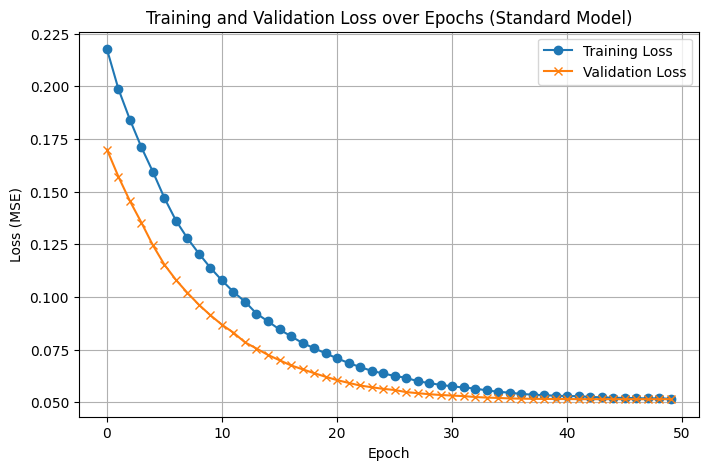

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Test MSE (original house price scale): 5301.3442


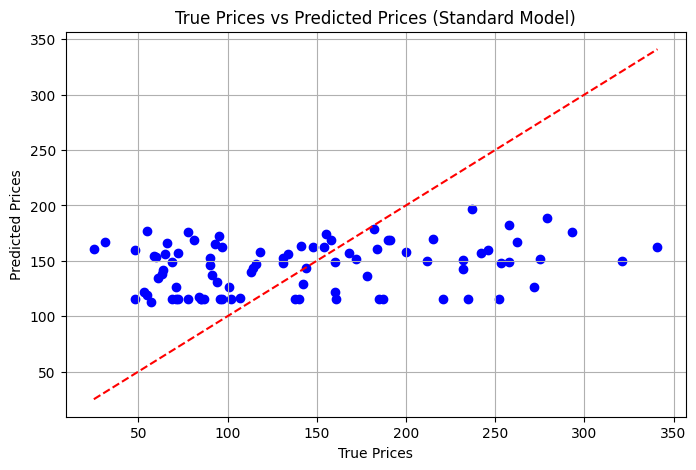

In [ ]:
#keras
model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=50,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()


#Concrete
Roughly 42 percent better lns for small 5 neuron model, keras better for 15

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_6               │ (None, 5)              │            45 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_7               │ (None, 5)              │            30 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_8               │ (None, 1)              │             6 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (648.00 B)

 Trainable params: 81 (648.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: -26282606.0000 - val_loss: -82443472.0000
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 850ms/step - loss: -80618904.0000 - val_loss: -82809888.0000
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 862ms/step - loss: -82908968.0000 - val_loss: -82692768.0000
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 840ms/step - loss: -83435304.0000 - val_loss: -83132152.0000
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 867ms/step - loss: -82013016.0000 - val_loss: -83156112.0000
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 813ms/step - loss: -82765480.0000 - val_loss: -83178704.0000
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 847ms/step - loss: -83194744.0000 - val_loss: -83508232.0000
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 22s 832ms/step - loss: -81966680.0000 - val_loss: -83710576.0000
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 829ms/step - loss: -82741360.0000 - val_loss: -83716600.0000
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 799ms/step - loss: -83352912.0000 - val_loss

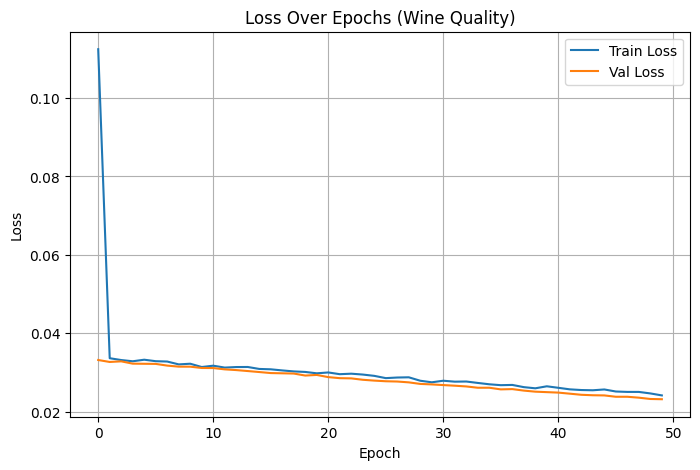

In [ ]:




data = pd.read_excel("/content/Concrete_Data.xls")
x_fp = data.iloc[:, :-1].values
y_fp = data.iloc[:, -1].values.reshape(-1, 1)


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp).nd, dtype=tf.float64)
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp).nd, dtype=tf.float64)


model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    LogSpaceDense(5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(5, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.01), loss=log_mse_loss)
model.summary()

history = model.fit(
    x_train_log, y_train_log,
    epochs=50,
    validation_data=(x_test_log, y_test_log),
    verbose=1
)


predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)

predictions_rescaled = predictions_fp * (y_max - y_min) + y_min
true_rescaled = lns_to_float(y_test_log) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(true_rescaled), np.array(predictions_rescaled))
print(f"Test MSE (Wine Quality): {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([lns_to_float(l) for l in history.history['loss']], label="Train Loss")
plt.plot([lns_to_float(l) for l in history.history['val_loss']], label="Val Loss")
plt.title("Loss Over Epochs (Wine Quality)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lns_to_float(-91132968.0000)

<tf.Tensor: shape=(), dtype=float64, numpy=0.023164378972185304>

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (648.00 B)

 Trainable params: 81 (648.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
 3/26 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1443

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.1447 - val_loss: 0.0888
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0780 - val_loss: 0.0765
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0703 - val_loss: 0.0665
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0541 - val_loss: 0.0605
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0533 - val_loss: 0.0540
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0549 - val_loss: 0.0496
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0465 - val_loss: 0.0472
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0424 - val_loss: 0.0457
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0411 - val_loss: 0.0440
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0418 - val_loss: 0.0427
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0399 - val_loss: 0.0419
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0384 - val_

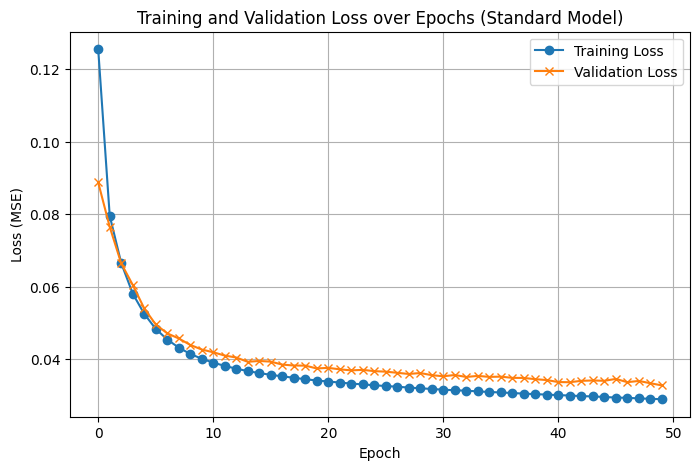

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Test MSE (original house price scale): 211.3446


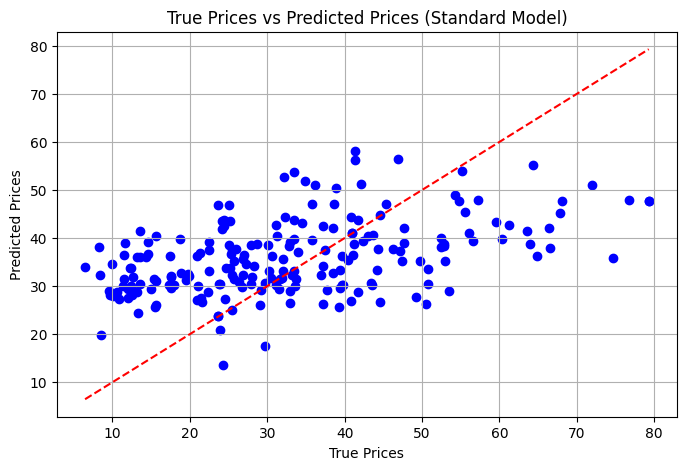

In [ ]:

data = pd.read_excel("/content/Concrete_Data.xls")
x_fp = data.iloc[:, :-1].values
y_fp = data.iloc[:, -1].values.reshape(-1, 1)
def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=5, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=50,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ log_space_dense_18              │ (None, 15)             │           135 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_19              │ (None, 15)             │           240 │
│ (LogSpaceDense)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ log_space_dense_20              │ (None, 1)              │            16 │
│ (LogSpaceDense)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (3.05 KB)

 Trainable params: 391 (3.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 6396219.0000 - val_loss: -33408194.0000
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - loss: -37469732.0000 - val_loss: -53202888.0000
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 970ms/step - loss: -54777432.0000 - val_loss: -66628080.0000
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 980ms/step - loss: -66879272.0000 - val_loss: -73565608.0000
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 956ms/step - loss: -71893008.0000 - val_loss: -76313880.0000
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 960ms/step - loss: -73144992.0000 - val_loss: -77182600.0000
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 972ms/step - loss: -76673184.0000 - val_loss: -77448480.0000
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: -76745216.0000 - val_loss: -77491440.0000
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 959ms/step - loss: -76169760.0000 - val_loss: -77473712.0000
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 970ms/step - loss: -76063536.0000 - val_loss: -77456

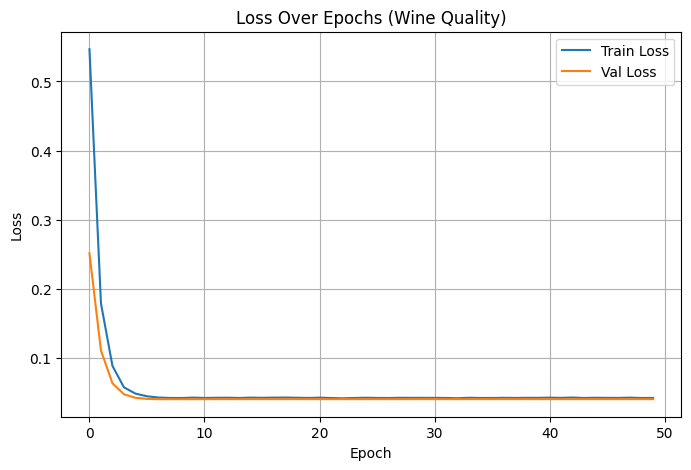

In [ ]:




data = pd.read_excel("/content/Concrete_Data.xls")
x_fp = data.iloc[:, :-1].values
y_fp = data.iloc[:, -1].values.reshape(-1, 1)


def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

x_train_log = tf.convert_to_tensor(xl.xlnsnp(x_train_fp).nd, dtype=tf.float64)
y_train_log = tf.convert_to_tensor(xl.xlnsnp(y_train_fp).nd, dtype=tf.float64)
x_test_log = tf.convert_to_tensor(xl.xlnsnp(x_test_fp).nd, dtype=tf.float64)
y_test_log = tf.convert_to_tensor(xl.xlnsnp(y_test_fp).nd, dtype=tf.float64)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    LogSpaceDense(15, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(15, activation=log_relu, dtype=tf.float64),
    LogSpaceDense(1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=LogSpaceSGD(learning_rate=0.01), loss=log_mse_loss)
model.summary()

history = model.fit(
    x_train_log, y_train_log,
    epochs=50,
    validation_data=(x_test_log, y_test_log),
    verbose=1
)


predictions_log = model.predict(x_test_log)
predictions_fp = lns_to_float(predictions_log)

predictions_rescaled = predictions_fp * (y_max - y_min) + y_min
true_rescaled = lns_to_float(y_test_log) * (y_max - y_min) + y_min

mse = mean_squared_error(np.array(true_rescaled), np.array(predictions_rescaled))
print(f"Test MSE (Wine Quality): {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot([lns_to_float(l) for l in history.history['loss']], label="Train Loss")
plt.plot([lns_to_float(l) for l in history.history['val_loss']], label="Val Loss")
plt.title("Loss Over Epochs (Wine Quality)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 15)             │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (3.05 KB)

 Trainable params: 391 (3.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.2014 - val_loss: 0.0530
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0442 - val_loss: 0.0415
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0411 - val_loss: 0.0381
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0373 - val_loss: 0.0356
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0392 - val_loss: 0.0340
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0346 - val_loss: 0.0328
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0342 - val_loss: 0.0320
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0315 - val_loss: 0.0312
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0322 - val_loss: 0.0307
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0317 - val_loss: 0.0302
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0293 - val_loss: 0.0295
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0297 - val_l

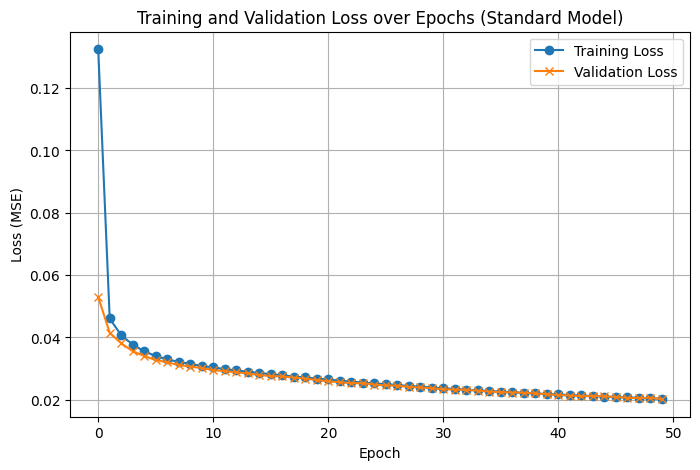

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Test MSE (original house price scale): 130.1135


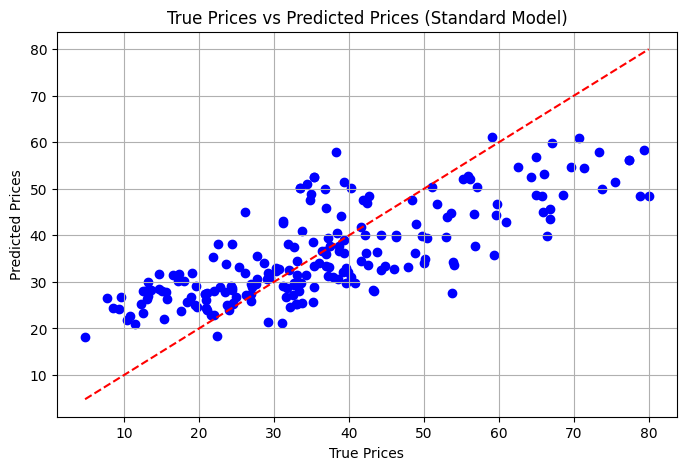

In [ ]:

data = pd.read_excel("/content/Concrete_Data.xls")
x_fp = data.iloc[:, :-1].values
y_fp = data.iloc[:, -1].values.reshape(-1, 1)
def min_max_scaling(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val + 1e-8), min_val, max_val

x_fp, x_min, x_max = min_max_scaling(x_fp)
y_fp, y_min, y_max = min_max_scaling(y_fp)

x_train_fp, x_test_fp, y_train_fp, y_test_fp = train_test_split(x_fp, y_fp, test_size=0.2)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fp.shape[1],), dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=15, activation='relu', dtype=tf.float64),
    tf.keras.layers.Dense(units=1, activation=None, dtype=tf.float64)
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

model.summary()


history = model.fit(
    x_train_fp.astype(np.float64),
    y_train_fp.astype(np.float64),
    epochs=50,
    verbose=1,
    validation_data=(x_test_fp.astype(np.float64), y_test_fp.astype(np.float64))
)


plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title("Training and Validation Loss over Epochs (Standard Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


predictions_fp = model.predict(x_test_fp.astype(np.float64))


predictions_fp_rescaled = predictions_fp.flatten() * (y_max - y_min) + y_min
y_true_fp_rescaled = y_test_fp * (y_max - y_min) + y_min


mse = mean_squared_error(y_true_fp_rescaled, predictions_fp_rescaled)
print(f"\nTest MSE (original house price scale): {mse:.4f}")


plt.figure(figsize=(8,5))
plt.scatter(y_true_fp_rescaled, predictions_fp_rescaled, color='blue')
plt.plot([min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         [min(y_true_fp_rescaled), max(y_true_fp_rescaled)],
         color='red', linestyle='--')
plt.title("True Prices vs Predicted Prices (Standard Model)")
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.grid(True)
plt.show()